# Extending the Analysis of the GSCDB137 Databse benchmark
Here, I extended the analysis of the GSCDB137 Databse benchmark for available functionals through correlation Plotting Results.

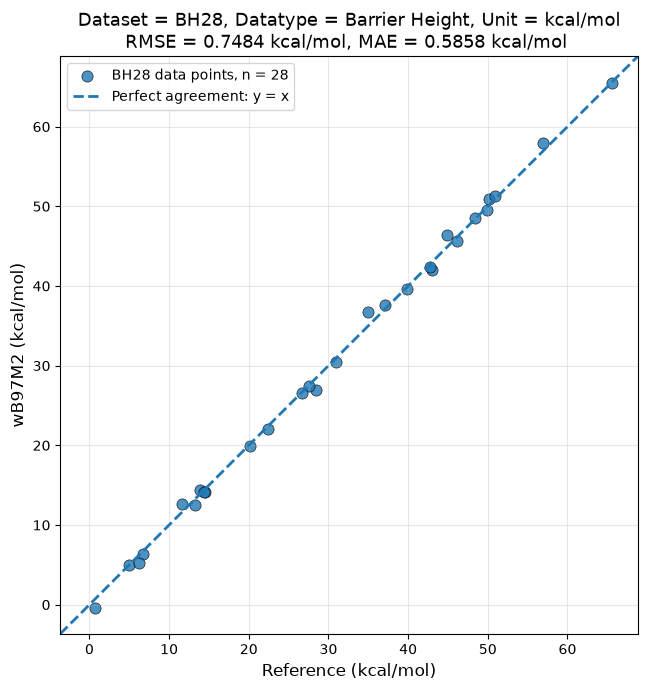

{'dataset': 'BH28', 'datatype': 'Barrier Height', 'description': 'Highly accurate subset chosen from BHPERI, CRBH20, BHDIV10, and PX13 sets', 'raw_unit': 'kcal/mol', 'converted_unit_from_notebook': 'kcal/mol', 'x_column': 'Reference', 'y_column': 'wB97M2', 'n_points': 28, 'rmse': np.float64(0.7483956819356008), 'mae': np.float64(0.5857980990748344), 'pearson_r': np.float64(0.9992210862584151)}


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("Results_values.csv")

df_dataset_info = pd.read_csv(r"..\Info\Datasets.csv")


def get_dataset_info(dataset_value, df_dataset_info):
    dataset_row = df_dataset_info[
        df_dataset_info["Name"] == dataset_value
    ]

    if dataset_row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = dataset_row["Datatype"].iloc[0]
        description = dataset_row["Description"].iloc[0]

    return datatype, description


def get_reference_unit(dataset_value):
    raw_unit = "kcal/mol"

    converted_units_from_notebook = {
        "Dip146": "Debye",
        "Pol130": "Å³",
        "HR46": "Å³",
        "T144": "Å³",
        "V30": "cm⁻¹"
    }

    converted_unit = converted_units_from_notebook.get(
        dataset_value,
        raw_unit
    )

    return raw_unit, converted_unit

def plot_reference_vs_functional(
    df,
    df_dataset_info,
    dataset_value,
    y_col,
    x_col="Reference",
    dataset_col="Dataset"
):
    
    required_columns = [
        dataset_col,
        x_col,
        y_col
    ]


    df_temp = df.copy()

    df_temp[dataset_col] = (
        df_temp[dataset_col]
        .astype(str)
        .str.strip()
    )

    selected_data = df_temp[
        df_temp[dataset_col] == dataset_value
    ].copy()

    if selected_data.empty:
        raise ValueError(
            f"No rows found for Dataset = '{dataset_value}'."
        )

    datatype, description = get_dataset_info(
        dataset_value,
        df_dataset_info
    )

    raw_unit, converted_unit = get_reference_unit(dataset_value)

    x = selected_data[x_col].to_numpy()
    y = selected_data[y_col].to_numpy()

    selected_data["Error"] = (
        selected_data[y_col] - selected_data[x_col]
    )

    selected_data["Absolute_Error"] = np.abs(
        selected_data["Error"]
    )

    selected_data["Squared_Error"] = (
        selected_data["Error"] ** 2
    )


    rmse = np.sqrt(
        np.mean(selected_data["Squared_Error"])
    )

    mae = np.mean(
        selected_data["Absolute_Error"]
    )


    pearson_r = np.corrcoef(x, y)[0, 1]


    minimum_value = min(
        x.min(),
        y.min()
    )

    maximum_value = max(
        x.max(),
        y.max()
    )

    value_range = maximum_value - minimum_value

    padding = (
        0.05 * value_range
        if value_range > 0
        else 1.0
    )

    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding


    plt.figure(figsize=(8, 7))

    # Scatter plot
    plt.scatter(
        x,
        y,
        s=65,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5,
        label=f"{dataset_value} data points, n = {len(selected_data)}"
    )

    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)

    plt.gca().set_aspect(
        "equal",
        adjustable="box"
    )

    plt.xlabel(
        f"{x_col} ({raw_unit})",
        fontsize=12
    )

    plt.ylabel(
        f"{y_col} ({raw_unit})",
        fontsize=12
    )

    plt.title(
        
        f"Dataset = {dataset_value}, Datatype = {datatype}, Unit = {raw_unit}\n"
        f"RMSE = {rmse:.4f} {raw_unit}, "
        f"MAE = {mae:.4f} {raw_unit} ",
        fontsize=13
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results = {
        "dataset": dataset_value,
        "datatype": datatype,
        "description": description,
        "raw_unit": raw_unit,
        "converted_unit_from_notebook": converted_unit,
        "x_column": x_col,
        "y_column": y_col,
        "n_points": len(selected_data),
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r
    }

    return results, selected_data


results, BH28_wB97M2_data = plot_reference_vs_functional(
    df=df,
    df_dataset_info=df_dataset_info,
    dataset_value="BH28",
    y_col="wB97M2"
)

print(results)

Dataset: HR46
Functional: wB97M2
Metric error: 0.0159982753
Standard metric error: 0.0126246381
Calculated NER: 1.2672264499
NER from Relative_metric_per_set.csv: 1.2672264499
Calculated NER matches relative-error file: True


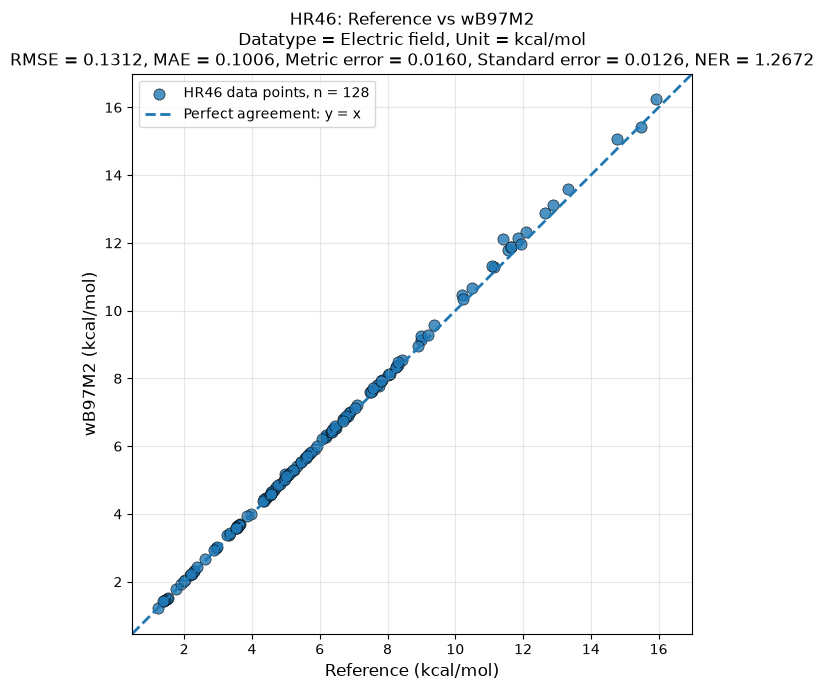


Complete results:
{'dataset': 'HR46', 'datatype': 'Electric field', 'description': 'Static polarizabilities (including individual components) for 46 systems at equilibrium', 'raw_unit': 'kcal/mol', 'converted_unit_from_notebook': 'Å³', 'x_column': 'Reference', 'y_column': 'wB97M2', 'n_points': 128, 'rmse': np.float64(0.1311784496099055), 'mae': np.float64(0.1005607600300778), 'pearson_r': np.float64(0.9997997410636043), 'metric_error': 0.0159982753078067, 'standard_metric_error': 0.0126246380902822, 'ner': 1.2672264498513706, 'ner_from_relative_file': 1.2672264498513706, 'ner_matches_relative_file': True}


In [22]:
df_metric_set = pd.read_csv("Errors_per_set_Metric.csv")

df_standard_errors = pd.read_csv(
    r"..\Info\Standard_errors.csv"
)

df_relative_metric = pd.read_csv("Relative_metric_per_set.csv")

def get_ner_values(
    dataset_value,
    functional,
    df_metric_set,
    df_standard_errors,
    df_relative_metric=None,
    rtol=1e-10,
    atol=1e-12,
):
    """
    Calculate the Normalized Error Ratio (NER) for one dataset
    and one functional.

    NER = metric error / standard metric error
    """

    metric_df = df_metric_set.copy()
    standard_df = df_standard_errors.copy()

    # Clean dataset names
    metric_df["Dataset"] = (
        metric_df["Dataset"]
        .astype(str)
        .str.strip()
    )

    standard_df["Dataset"] = (
        standard_df["Dataset"]
        .astype(str)
        .str.strip()
    )

    dataset_value = str(dataset_value).strip()

    # Check that the functional exists
    if functional not in metric_df.columns:
        raise KeyError(
            f"Functional '{functional}' was not found in "
            "Errors_per_set_Metric.csv."
        )

    # Select dataset rows
    metric_row = metric_df[
        metric_df["Dataset"] == dataset_value
    ]

    standard_row = standard_df[
        standard_df["Dataset"] == dataset_value
    ]

    if metric_row.empty:
        raise ValueError(
            f"Dataset '{dataset_value}' was not found in "
            "Errors_per_set_Metric.csv."
        )

    if standard_row.empty:
        raise ValueError(
            f"Dataset '{dataset_value}' was not found in "
            "Standard_errors.csv."
        )

    if len(metric_row) > 1:
        raise ValueError(
            f"Dataset '{dataset_value}' occurs more than once in "
            "Errors_per_set_Metric.csv."
        )

    if len(standard_row) > 1:
        raise ValueError(
            f"Dataset '{dataset_value}' occurs more than once in "
            "Standard_errors.csv."
        )

    # Functional's metric error for the selected dataset
    metric_error = float(
        metric_row[functional].iloc[0]
    )

    # Benchmark standard metric for the selected dataset
    standard_error = float(
        standard_row["Metric"].iloc[0]
    )

    if not np.isfinite(standard_error):
        raise ValueError(
            f"The standard error for '{dataset_value}' is not finite."
        )

    if standard_error == 0:
        raise ZeroDivisionError(
            f"The standard error for '{dataset_value}' is zero."
        )

    # Calculate NER
    ner_calculated = metric_error / standard_error

    # Default values when no reference relative-error file is supplied
    ner_from_file = np.nan
    ner_matches_file = None

    # Compare against Relative_metric_per_set.csv
    if df_relative_metric is not None:
        relative_df = df_relative_metric.copy()

        relative_df["Dataset"] = (
            relative_df["Dataset"]
            .astype(str)
            .str.strip()
        )

        if functional not in relative_df.columns:
            raise KeyError(
                f"Functional '{functional}' was not found in "
                "Relative_metric_per_set.csv."
            )

        relative_row = relative_df[
            relative_df["Dataset"] == dataset_value
        ]

        if relative_row.empty:
            raise ValueError(
                f"Dataset '{dataset_value}' was not found in "
                "Relative_metric_per_set.csv."
            )

        if len(relative_row) > 1:
            raise ValueError(
                f"Dataset '{dataset_value}' occurs more than once in "
                "Relative_metric_per_set.csv."
            )

        ner_from_file = float(
            relative_row[functional].iloc[0]
        )

        ner_matches_file = bool(
            np.isclose(
                ner_calculated,
                ner_from_file,
                rtol=rtol,
                atol=atol,
                equal_nan=True,
            )
        )

    return {
        "metric_error": metric_error,
        "standard_error": standard_error,
        "ner": ner_calculated,
        "ner_from_file": ner_from_file,
        "ner_matches_file": ner_matches_file,
    }


def plot_reference_vs_functional(
    df,
    df_dataset_info,
    df_metric_set,
    df_standard_errors,
    df_relative_metric,
    dataset_value,
    y_col,
    x_col="Reference",
    dataset_col="Dataset",
):
    required_columns = [
        dataset_col,
        x_col,
        y_col,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing columns in Results_values.csv: "
            f"{missing_columns}"
        )

    df_temp = df.copy()

    # Clean dataset names
    df_temp[dataset_col] = (
        df_temp[dataset_col]
        .astype(str)
        .str.strip()
    )

    dataset_value = str(dataset_value).strip()

    # Select the requested dataset
    selected_data = df_temp[
        df_temp[dataset_col] == dataset_value
    ].copy()

    if selected_data.empty:
        raise ValueError(
            f"No rows found for Dataset = '{dataset_value}'."
        )

    # Convert plotting columns to numeric
    selected_data[x_col] = pd.to_numeric(
        selected_data[x_col],
        errors="coerce",
    )

    selected_data[y_col] = pd.to_numeric(
        selected_data[y_col],
        errors="coerce",
    )

    # Remove rows where x or y is missing
    selected_data = selected_data.dropna(
        subset=[x_col, y_col]
    ).copy()

    if selected_data.empty:
        raise ValueError(
            f"No valid numeric values remain for "
            f"{x_col} and {y_col}."
        )

    datatype, description = get_dataset_info(
        dataset_value,
        df_dataset_info,
    )

    raw_unit, converted_unit = get_reference_unit(
        dataset_value
    )

    x = selected_data[x_col].to_numpy()
    y = selected_data[y_col].to_numpy()

    # Calculate individual errors
    selected_data["Error"] = (
        selected_data[y_col]
        - selected_data[x_col]
    )

    selected_data["Absolute_Error"] = np.abs(
        selected_data["Error"]
    )

    selected_data["Squared_Error"] = (
        selected_data["Error"] ** 2
    )

    # Ordinary RMSE and MAE from Results_values.csv
    rmse = np.sqrt(
        np.mean(selected_data["Squared_Error"])
    )

    mae = np.mean(
        selected_data["Absolute_Error"]
    )

    # Pearson correlation
    if len(selected_data) > 1:
        pearson_r = np.corrcoef(x, y)[0, 1]
    else:
        pearson_r = np.nan

    # Obtain the benchmark metric error and NER
    ner_results = get_ner_values(
        dataset_value=dataset_value,
        functional=y_col,
        df_metric_set=df_metric_set,
        df_standard_errors=df_standard_errors,
        df_relative_metric=df_relative_metric,
    )

    metric_error = ner_results["metric_error"]
    standard_error = ner_results["standard_error"]
    ner = ner_results["ner"]
    ner_from_file = ner_results["ner_from_file"]
    ner_matches_file = ner_results["ner_matches_file"]

    # Print NER information
    print(f"Dataset: {dataset_value}")
    print(f"Functional: {y_col}")
    print(f"Metric error: {metric_error:.10f}")
    print(f"Standard metric error: {standard_error:.10f}")
    print(f"Calculated NER: {ner:.10f}")
    print(
        "NER from Relative_metric_per_set.csv: "
        f"{ner_from_file:.10f}"
    )
    print(
        "Calculated NER matches relative-error file: "
        f"{ner_matches_file}"
    )

    # Determine equal x and y limits
    minimum_value = min(
        x.min(),
        y.min(),
    )

    maximum_value = max(
        x.max(),
        y.max(),
    )

    value_range = maximum_value - minimum_value

    padding = (
        0.05 * value_range
        if value_range > 0
        else 1.0
    )

    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding

    # Create plot
    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y,
        s=65,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5,
        label=(
            f"{dataset_value} data points, "
            f"n = {len(selected_data)}"
        ),
    )

    # Perfect-agreement line
    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x",
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)

    plt.gca().set_aspect(
        "equal",
        adjustable="box",
    )

    plt.xlabel(
        f"{x_col} ({raw_unit})",
        fontsize=12,
    )

    plt.ylabel(
        f"{y_col} ({raw_unit})",
        fontsize=12,
    )

    plt.title(
        f"{dataset_value}: {x_col} vs {y_col}\n"
        f"Datatype = {datatype}, Unit = {raw_unit}\n"
        f"RMSE = {rmse:.4f}, MAE = {mae:.4f}, "
        f"Metric error = {metric_error:.4f}, "
        f"Standard error = {standard_error:.4f}, "
        f"NER = {ner:.4f}",
        fontsize=12,
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results = {
        "dataset": dataset_value,
        "datatype": datatype,
        "description": description,
        "raw_unit": raw_unit,
        "converted_unit_from_notebook": converted_unit,
        "x_column": x_col,
        "y_column": y_col,
        "n_points": len(selected_data),
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "metric_error": metric_error,
        "standard_metric_error": standard_error,
        "ner": ner,
        "ner_from_relative_file": ner_from_file,
        "ner_matches_relative_file": ner_matches_file,
    }

    return results, selected_data

results, HR46_wB97M2_data = plot_reference_vs_functional(
    df=df,
    df_dataset_info=df_dataset_info,
    df_metric_set=df_metric_set,
    df_standard_errors=df_standard_errors,
    df_relative_metric=df_relative_metric,
    dataset_value="HR46",
    y_col="wB97M2",
)

print("\nComplete results:")
print(results)

Datatype: Barrier Height
Functional: wB97M2
Datasets: 12
Data points: 1124
Pooled RMSE: 1.8300229902
Pooled MAE: 1.2214142729
Pearson r: 0.9962183933
Calculated Mean Relative Error: 0.6682301510
Mean Relative Error from Statistical_errors.csv: 0.6682301510
MRE values match: True


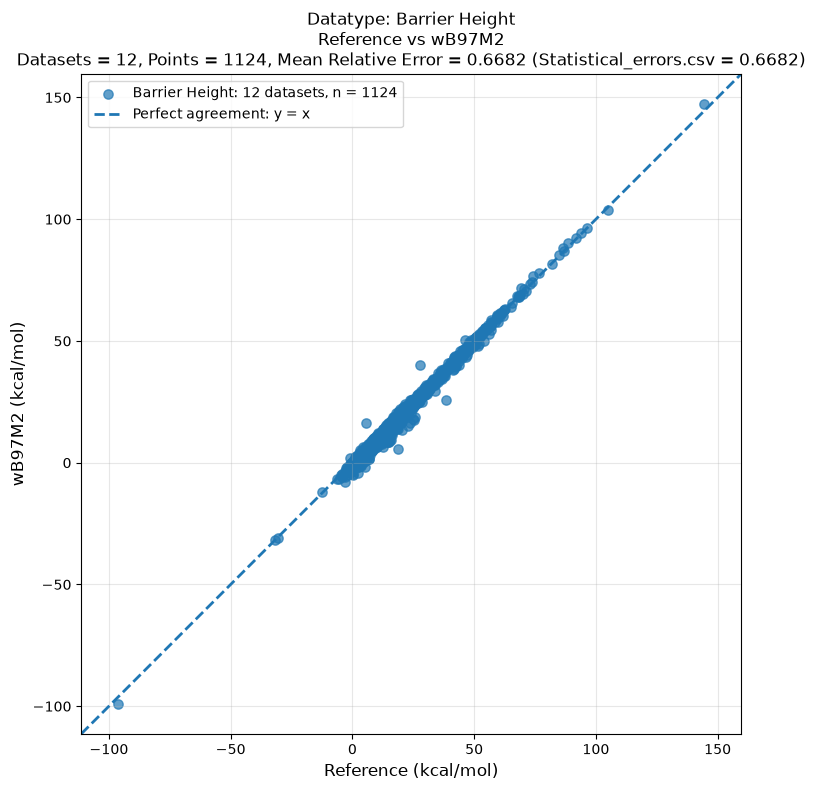

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Change only these two values
DATATYPE = "Barrier Height"
FUNCTIONAL = "wB97M2"

# Load files
results = pd.read_csv("Results_values.csv")
datasets_info = pd.read_csv(r"..\Info\Datasets.csv")
relative_errors = pd.read_csv("Relative_metric_per_set.csv")
statistical_errors = pd.read_csv(
    "Statistical_errors.csv",
    index_col=0
)

# Find all datasets belonging to the selected Datatype
datasets = datasets_info.loc[
    datasets_info["Datatype"] == DATATYPE,
    "Name"
].tolist()

# Select all Reference and functional values for the Datatype
selected = results.loc[
    results["Dataset"].isin(datasets),
    ["Reference", FUNCTIONAL]
].dropna()

x = selected["Reference"].to_numpy()
y = selected[FUNCTIONAL].to_numpy()

# Mean Relative Error = mean of dataset-level NER values
mre = relative_errors.loc[
    relative_errors["Dataset"].isin(datasets),
    FUNCTIONAL
].mean()

# Stored datatype MRE
mre_from_file = statistical_errors.loc[
    f"Mean {DATATYPE}",
    FUNCTIONAL
]

# Pooled correlation statistics
rmse = np.sqrt(np.mean((y - x) ** 2))
mae = np.mean(np.abs(y - x))
pearson_r = np.corrcoef(x, y)[0, 1]

print(f"Datatype: {DATATYPE}")
print(f"Functional: {FUNCTIONAL}")
print(f"Datasets: {len(datasets)}")
print(f"Data points: {len(selected)}")
print(f"Pooled RMSE: {rmse:.10f}")
print(f"Pooled MAE: {mae:.10f}")
print(f"Pearson r: {pearson_r:.10f}")
print(f"Calculated Mean Relative Error: {mre:.10f}")
print(
    "Mean Relative Error from Statistical_errors.csv: "
    f"{mre_from_file:.10f}"
)
print(
    f"MRE values match: "
    f"{np.isclose(mre, mre_from_file)}"
)

# Equal x-axis and y-axis ranges
minimum = min(x.min(), y.min())
maximum = max(x.max(), y.max())

padding = (
    0.05 * (maximum - minimum)
    if maximum > minimum
    else 1
)

plot_min = minimum - padding
plot_max = maximum + padding

energy_types = {
    "Barrier Height",
    "Intramolecular Noncovalent",
    "Isomerization",
    "Noncovalent",
    "Thermochemistry",
    "Transition Metal"
}

unit = (
    "kcal/mol"
    if DATATYPE in energy_types
    else "cm⁻¹"
    if DATATYPE == "Frequency"
    else "dataset-specific units"
)

# Correlation plot
plt.figure(figsize=(9, 8))

plt.scatter(
    x,
    y,
    s=45,
    alpha=0.7,
    label=(
        f"{DATATYPE}: {len(datasets)} datasets, "
        f"n = {len(selected)}"
    )
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=2,
    label="Perfect agreement: y = x"
)

plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)

plt.gca().set_aspect(
    "equal",
    adjustable="box"
)

plt.xlabel(
    f"Reference ({unit})",
    fontsize=12
)

plt.ylabel(
    f"{FUNCTIONAL} ({unit})",
    fontsize=12
)

plt.title(
    f"Datatype: {DATATYPE}\n"
    f"Reference vs {FUNCTIONAL}\n"
    f"Datasets = {len(datasets)}, "
    f"Points = {len(selected)}, "
    f"Mean Relative Error = {mre:.4f} "
    f"(Statistical_errors.csv = "
    f"{mre_from_file:.4f})",
    fontsize=12
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from ase.io import read

atoms = read("../xyz_files/DARC_P1.xyz")

atoms.info["charge"] = 0
atoms.info["spin"] = 1
atoms.info["external_field"] = [0.0, 0.0, 0.0]

In [ ]:
from mace.calculators import mace_polar
from ase import units

calc = mace_polar(
    model="polar-1-m",
    device="cuda",
    default_dtype="float64"
)

atoms.calc = calc
energy_eV = atoms.get_potential_energy()
energy_Ha = energy_eV / units.Hartree

In [ ]:
atoms.info["external_field"] = [0.0, 0.0, 0.0]

In [ ]:
model="polar-1-s"
model="polar-1-m"
model="polar-1-l"